# Final pretraining split inspection

This notebook audits the processed `train`, `validation`, and `test` Parquet files before tokenizer training. It is read-only: no source or split file is modified. The checks cover schema, manifest consistency, disk/row sizes, source composition, missing and empty values, sampled document-length distributions, readable instances, and exact identifier/text-hash leakage across splits.

In [1]:
from collections import Counter
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

SEED = 42
SAMPLE_PER_SPLIT = 5_000
EXAMPLES_PER_SPLIT = 2
MAX_EXAMPLE_CHARACTERS = 4_000
RUN_FULL_UNIQUENESS_CHECK = True
SPLITS = ('train', 'validation', 'test')
EXPECTED_COLUMNS = [
    'doc_id', 'text', 'source', 'source_id', 'language',
    'url', 'text_sha256', 'metadata_json',
]

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'scripts' / 'build_pretraining_dataset.py').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the attentionMaps repository.')

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
from scripts.utils.nepali_text import devanagari_letter_stats

# Change this name to inspect another processed run.
PREFERRED_RUN = 'nepali_pretraining_small'
DATASET_ROOT = REPO_ROOT / 'data' / 'processed' / PREFERRED_RUN
if not all((DATASET_ROOT / f'{split}.parquet').is_file() for split in SPLITS):
    candidates = sorted(
        path for path in (REPO_ROOT / 'data' / 'processed').iterdir()
        if path.is_dir() and all((path / f'{split}.parquet').is_file() for split in SPLITS)
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f'Processed run {DATASET_ROOT} was not found. Set PREFERRED_RUN. '
            f'Available complete runs: {[path.name for path in candidates]}'
        )
    DATASET_ROOT = candidates[0]

SPLIT_PATHS = {split: DATASET_ROOT / f'{split}.parquet' for split in SPLITS}
MANIFEST_PATH = DATASET_ROOT / 'build_manifest.json'
print(f'Inspecting: {DATASET_ROOT}')

Inspecting: /home/aixi/attentionMaps/data/processed/nepali_pretraining_small


## Build manifest and requested data policy

The manifest is the audit record for source fractions, split ratios, seed, deduplication, input cleaning manifests, and final counts. The notebook compares it with physical Parquet metadata rather than assuming it is correct.

In [2]:
assert MANIFEST_PATH.is_file(), f'Missing build manifest: {MANIFEST_PATH}'
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
manifest_overview = {
    'status': manifest.get('status'),
    'created_at_utc': manifest.get('created_at_utc'),
    'seed': manifest.get('seed'),
    'input_stage': manifest.get('input_stage'),
    'deduplicate_exact_text': manifest.get('deduplicate_exact_text'),
    'total_documents': manifest.get('total_documents'),
    'global_fraction': manifest.get('sampling', {}).get('global_fraction'),
}
display(pd.Series(manifest_overview, name='value').to_frame())
display(pd.DataFrame({
    'requested_split_ratio': manifest.get('split_ratios', {}),
    'manifest_documents': manifest.get('split_counts', {}),
}))
display(pd.DataFrame({
    'source_fraction': manifest.get('sampling', {}).get('source_fractions', {}),
    'effective_fraction': manifest.get('sampling', {}).get('effective_fractions', {}),
}))

,value
status,complete
created_at_utc,2026-08-23T16:05:54.745571+00:00
seed,42
input_stage,cleaned
deduplicate_exact_text,True
total_documents,12732
global_fraction,1.0


,requested_split_ratio,manifest_documents
train,0.98,12470
validation,0.01,121
test,0.01,141


,source_fraction,effective_fraction
nepali_pdf,1.00,1.00
nepali_news,0.01,0.01
nepali_lyrics,1.00,1.00


## Physical Parquet structure

Parquet metadata provides exact row counts, file sizes, row-group counts, and schemas without loading full text columns into memory. All three splits must have the same canonical schema.

In [3]:
physical_rows = []
schemas = {}
for split, path in SPLIT_PATHS.items():
    parquet_file = pq.ParquetFile(path)
    schemas[split] = parquet_file.schema_arrow
    physical_rows.append({
        'split': split,
        'documents': parquet_file.metadata.num_rows,
        'file_mib': path.stat().st_size / 1024**2,
        'row_groups': parquet_file.metadata.num_row_groups,
        'columns': parquet_file.metadata.num_columns,
        'compression': ', '.join(sorted({
            parquet_file.metadata.row_group(group).column(column).compression
            for group in range(parquet_file.metadata.num_row_groups)
            for column in range(parquet_file.metadata.num_columns)
        })),
    })

physical = pd.DataFrame(physical_rows).set_index('split')
physical['actual_ratio'] = physical['documents'] / physical['documents'].sum()
physical['manifest_documents'] = pd.Series(manifest.get('split_counts', {}))
physical['count_matches_manifest'] = physical['documents'].eq(physical['manifest_documents'])
display(physical.style.format({'file_mib': '{:,.2f}', 'actual_ratio': '{:.2%}'}))

reference_schema = schemas['train']
assert reference_schema.names == EXPECTED_COLUMNS, (reference_schema.names, EXPECTED_COLUMNS)
assert all(schema.equals(reference_schema) for schema in schemas.values()), 'Split schemas differ'
assert physical['count_matches_manifest'].all(), 'Physical row counts differ from manifest'
assert physical['documents'].sum() == manifest.get('total_documents'), 'Total count mismatch'
display(pd.DataFrame({
    'column': reference_schema.names,
    'arrow_type': [str(field.type) for field in reference_schema],
    'nullable': [field.nullable for field in reference_schema],
}))

,documents,file_mib,row_groups,columns,compression,actual_ratio,manifest_documents,count_matches_manifest
split,,,,,,,,
train,12470,29.63,7,8,ZSTD,97.94%,12470,True
validation,121,0.40,1,8,ZSTD,0.95%,121,True
test,141,0.51,1,8,ZSTD,1.11%,141,True


,column,arrow_type,nullable
0,doc_id,string,True
1,text,string,True
2,source,string,True
3,source_id,string,True
4,language,string,True
5,url,string,True
6,text_sha256,string,True
7,metadata_json,string,True


## Full-split source composition and basic quality

This scan reads selected columns in bounded batches. It counts source labels, nulls in every canonical column, blank training texts, malformed hash lengths, and invalid JSON metadata across the complete splits.

In [4]:
source_counts = {}
quality_rows = []
for split, path in SPLIT_PATHS.items():
    counts = Counter()
    null_counts = Counter()
    blank_texts = 0
    malformed_doc_ids = 0
    malformed_text_hashes = 0
    invalid_metadata_json = 0
    parquet_file = pq.ParquetFile(path)
    for batch in parquet_file.iter_batches(batch_size=8_192, columns=EXPECTED_COLUMNS):
        for name, column in zip(batch.schema.names, batch.columns):
            null_counts[name] += column.null_count
        counts.update(value or '<NULL>' for value in batch.column('source').to_pylist())
        texts = batch.column('text')
        trimmed = pc.utf8_trim_whitespace(texts)
        blank_texts += int(pc.sum(pc.equal(pc.utf8_length(trimmed), 0)).as_py() or 0)
        malformed_doc_ids += sum(len(value or '') != 64 for value in batch.column('doc_id').to_pylist())
        malformed_text_hashes += sum(len(value or '') != 64 for value in batch.column('text_sha256').to_pylist())
        for value in batch.column('metadata_json').to_pylist():
            try:
                decoded = json.loads(value)
                if not isinstance(decoded, dict):
                    invalid_metadata_json += 1
            except (TypeError, json.JSONDecodeError):
                invalid_metadata_json += 1
    source_counts[split] = counts
    quality_rows.append({
        'split': split, 'blank_texts': blank_texts,
        'malformed_doc_ids': malformed_doc_ids,
        'malformed_text_hashes': malformed_text_hashes,
        'invalid_metadata_json': invalid_metadata_json,
        **{f'null_{name}': null_counts[name] for name in EXPECTED_COLUMNS},
    })

source_table = pd.DataFrame(source_counts).fillna(0).astype(int).T
source_table['total'] = source_table.sum(axis=1)
display(source_table)
quality = pd.DataFrame(quality_rows).set_index('split')
display(quality)
assert quality[['blank_texts', 'malformed_doc_ids', 'malformed_text_hashes', 'invalid_metadata_json']].to_numpy().sum() == 0
assert source_table['total'].to_dict() == physical['documents'].to_dict()

,nepali_pdf,nepali_news,nepali_lyrics,total
train,3713,8656,101,12470
validation,38,81,2,121
test,37,102,2,141


,blank_texts,malformed_doc_ids,malformed_text_hashes,invalid_metadata_json,null_doc_id,null_text,null_source,null_source_id,null_language,null_url,null_text_sha256,null_metadata_json
split,,,,,,,,,,,,
train,0,0,0,0,0,0,0,0,0,101,0,0
validation,0,0,0,0,0,0,0,0,0,2,0,0
test,0,0,0,0,0,0,0,0,0,2,0,0


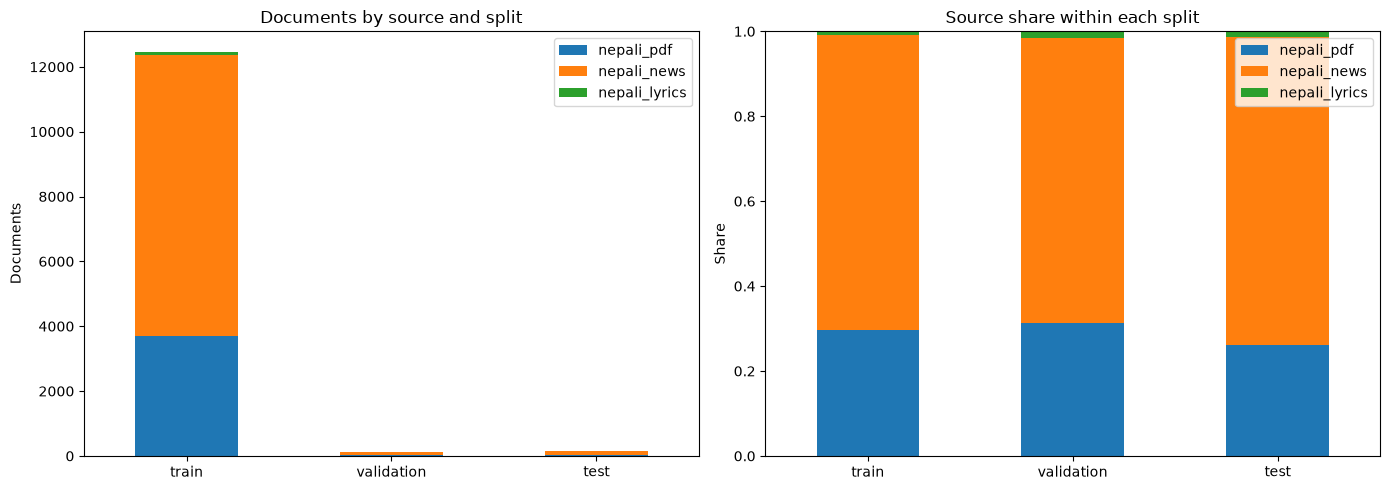

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
source_table.drop(columns='total').plot.bar(stacked=True, ax=axes[0])
axes[0].set_title('Documents by source and split')
axes[0].set_ylabel('Documents')
axes[0].tick_params(axis='x', rotation=0)

source_share = source_table.drop(columns='total').div(source_table['total'], axis=0)
source_share.plot.bar(stacked=True, ax=axes[1])
axes[1].set_title('Source share within each split')
axes[1].set_ylabel('Share')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Reproducible bounded sample for text statistics

Character and whitespace-word lengths are pre-tokenization diagnostics, not token counts. The sampler chooses exact global row positions and reads only relevant Parquet row groups, so the notebook also works with the full corpus without loading all text into a dataframe.

In [6]:
def sample_parquet(path: Path, sample_size: int, seed: int) -> pd.DataFrame:
    parquet_file = pq.ParquetFile(path)
    total = parquet_file.metadata.num_rows
    count = min(sample_size, total)
    selected = np.sort(np.random.default_rng(seed).choice(total, size=count, replace=False))
    pieces = []
    cursor = 0
    for row_group in range(parquet_file.metadata.num_row_groups):
        rows = parquet_file.metadata.row_group(row_group).num_rows
        left = np.searchsorted(selected, cursor, side='left')
        right = np.searchsorted(selected, cursor + rows, side='left')
        if left != right:
            offsets = selected[left:right] - cursor
            table = parquet_file.read_row_group(row_group, columns=EXPECTED_COLUMNS)
            pieces.append(table.take(pa.array(offsets, type=pa.int64())))
        cursor += rows
    return pa.concat_tables(pieces).to_pandas()

sampled_frames = []
for index, (split, path) in enumerate(SPLIT_PATHS.items()):
    frame = sample_parquet(path, SAMPLE_PER_SPLIT, SEED + index)
    frame['split'] = split
    sampled_frames.append(frame)
sample = pd.concat(sampled_frames, ignore_index=True)
sample['characters'] = sample['text'].str.len()
sample['utf8_bytes'] = sample['text'].map(lambda text: len(text.encode('utf-8')))
sample['whitespace_words'] = sample['text'].map(lambda text: len(text.split()))
sample['lines'] = sample['text'].map(lambda text: text.count('\n') + 1)
sample['devanagari_ratio'] = sample['text'].map(lambda text: devanagari_letter_stats(text)[0])
print(f'Sampled {len(sample):,} documents from {physical["documents"].sum():,} total.')

Sampled 5,262 documents from 12,732 total.


In [7]:
def length_summary(group: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'sample_documents': len(group),
        'characters_median': group['characters'].median(),
        'characters_p95': group['characters'].quantile(.95),
        'characters_p99': group['characters'].quantile(.99),
        'characters_max': group['characters'].max(),
        'words_median': group['whitespace_words'].median(),
        'lines_median': group['lines'].median(),
        'devanagari_ratio_median': group['devanagari_ratio'].median(),
    })

lengths_by_split = sample.groupby('split', sort=False).apply(length_summary, include_groups=False)
lengths_by_source = sample.groupby('source', sort=False).apply(length_summary, include_groups=False)
display(lengths_by_split.style.format({
    'characters_median': '{:,.0f}', 'characters_p95': '{:,.0f}',
    'characters_p99': '{:,.0f}', 'characters_max': '{:,.0f}',
    'words_median': '{:,.0f}', 'lines_median': '{:,.0f}',
    'devanagari_ratio_median': '{:.1%}',
}))
display(lengths_by_source.style.format({
    'characters_median': '{:,.0f}', 'characters_p95': '{:,.0f}',
    'characters_p99': '{:,.0f}', 'characters_max': '{:,.0f}',
    'words_median': '{:,.0f}', 'lines_median': '{:,.0f}',
    'devanagari_ratio_median': '{:.1%}',
}))

,sample_documents,characters_median,characters_p95,characters_p99,characters_max,words_median,lines_median,devanagari_ratio_median
split,,,,,,,,
train,5000.000000,"1,524","11,636","44,360","9,519,310",223,14,100.0%
validation,121.000000,"1,436","30,644","44,269","440,349",224,17,100.0%
test,141.000000,"1,518","5,068","129,933","423,340",223,15,100.0%


,sample_documents,characters_median,characters_p95,characters_p99,characters_max,words_median,lines_median,devanagari_ratio_median
source,,,,,,,,
nepali_pdf,1591.000000,"1,744","43,444","130,487","9,519,310",245,68,100.0%
nepali_news,3629.000000,"1,358","4,391","8,797","26,725",207,9,100.0%
nepali_lyrics,42.000000,874,"1,312","1,522","1,615",153,29,100.0%


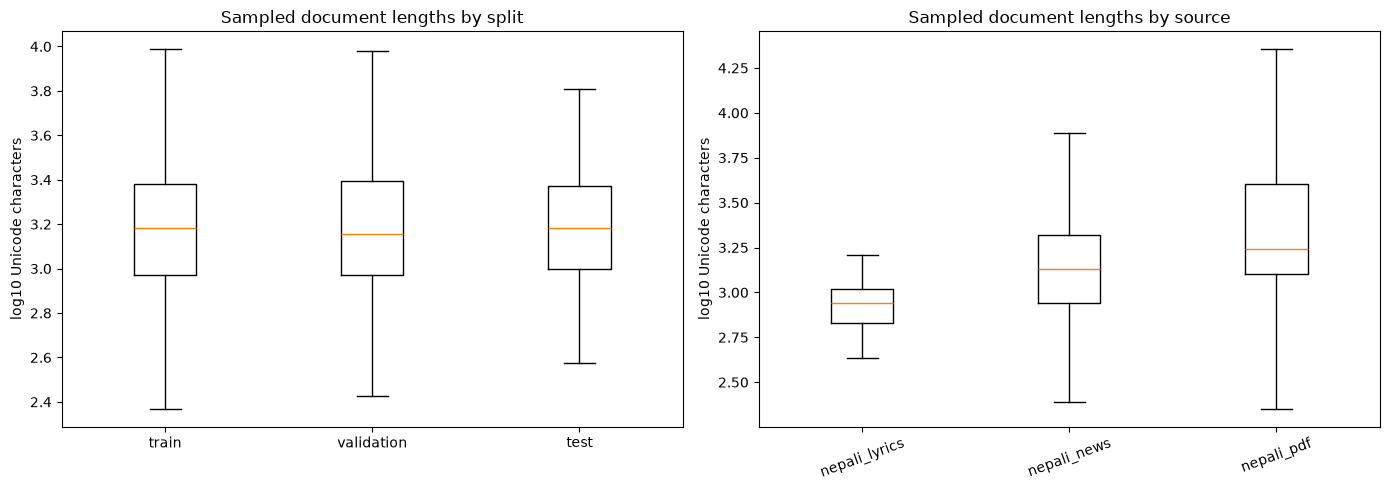

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(
    [np.log10(sample.loc[sample['split'].eq(split), 'characters'].clip(lower=1)) for split in SPLITS],
    tick_labels=SPLITS, showfliers=False,
)
axes[0].set_title('Sampled document lengths by split')
axes[0].set_ylabel('log10 Unicode characters')

source_order = sorted(sample['source'].unique())
axes[1].boxplot(
    [np.log10(sample.loc[sample['source'].eq(source), 'characters'].clip(lower=1)) for source in source_order],
    tick_labels=source_order, showfliers=False,
)
axes[1].set_title('Sampled document lengths by source')
axes[1].set_ylabel('log10 Unicode characters')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Inspect readable instances

The following cell prints reproducible examples with provenance and parsed metadata. Very long text is capped to keep notebook output usable; raise `MAX_EXAMPLE_CHARACTERS` when a complete document is required.

In [9]:
for split in SPLITS:
    examples = sample.loc[sample['split'].eq(split)].sample(
        n=min(EXAMPLES_PER_SPLIT, sample['split'].eq(split).sum()),
        random_state=SEED,
    )
    for number, (_, row) in enumerate(examples.iterrows(), start=1):
        text = row['text']
        shown = text[:MAX_EXAMPLE_CHARACTERS]
        suffix = f'\n… [truncated {len(text) - len(shown):,} characters]' if len(text) > len(shown) else ''
        print('=' * 100)
        print(f'{split.upper()} EXAMPLE {number}')
        print(f"source={row['source']} source_id={row['source_id']} doc_id={row['doc_id']}")
        print(f"characters={row['characters']:,} words={row['whitespace_words']:,} url={row['url']}")
        print('metadata:', json.dumps(json.loads(row['metadata_json']), ensure_ascii=False, indent=2))
        print('text:')
        print(shown + suffix)

TRAIN EXAMPLE 1
source=nepali_pdf source_id=fbe3d8282d511b9b05c53ed8226e7bed doc_id=a38968be5335f9b28c5a7b2cfd6c3e96abc1610900abc682c332e41a8fe36ff2
characters=2,935 words=440 url=https://bharatpurmun.gov.np/ne/content/%E0%A4%86-%E0%A4%B5-%E0%A5%A8%E0%A5%A6%E0%A5%AE%E0%A5%A7-%E0%A5%AE%E0%A5%A8-%E0%A4%95%E0%A5%8B-%E0%A4%AF%E0%A5%8B%E0%A4%9C%E0%A4%A8%E0%A4%BE-%E0%A4%95%E0%A4%BF%E0%A4%A4%E0%A4%BE%E0%A4%B5
metadata: {
  "cleaning": {
    "input_devanagari_letters": 1474,
    "input_devanagari_ratio": 0.87374,
    "output_devanagari_letters": 1474,
    "output_devanagari_ratio": 1.0
  },
  "devanagari_letters": 1474,
  "devanagari_ratio": 1.0
}
text:
नेपाली
भरतपुर महानगरपालिका
नगर कार्यपालिकाको कार्यालय,बागमती प्रदेश,नेपाल
गृहपृष्ठ
परिचय
संक्षिप्त परिचय
महानगरपालिकाको परिचय
तथ्यांकिय जानकारी
संगठनात्मक स्वरुप
वार्ड प्रोफाइल
कर्मचारी
कार्यपालिका
सम्पर्क नम्वर सहित जनप्रतिनिधि ज्यूहरुको विवरण
वडा सचिवको सम्पर्क नम्वर
कार्यक्रम तथा परियोजना
बजेट तथा कार्यक्रम
प्रतिवेदन
वार्षिक प्रगति प्रतिवेदन

## Exact uniqueness and cross-split leakage

`doc_id` checks source-identity collisions; `text_sha256` checks exact cleaned-text duplicates. Full within-split distinct counting reads one compact string column at a time. Cross-split checking stores only validation/test values and streams train, keeping memory bounded by the held-out sets. Set `RUN_FULL_UNIQUENESS_CHECK = False` only on a severely memory-constrained machine.

In [10]:
uniqueness_rows = []
if RUN_FULL_UNIQUENESS_CHECK:
    for split, path in SPLIT_PATHS.items():
        total = physical.loc[split, 'documents']
        row = {'split': split, 'documents': total}
        for column in ('doc_id', 'text_sha256'):
            values = pq.read_table(path, columns=[column])[column]
            distinct = int(pc.count_distinct(values).as_py())
            row[f'unique_{column}'] = distinct
            row[f'duplicate_{column}'] = total - distinct
        uniqueness_rows.append(row)
    uniqueness = pd.DataFrame(uniqueness_rows).set_index('split')
    display(uniqueness)
    assert uniqueness[['duplicate_doc_id', 'duplicate_text_sha256']].to_numpy().sum() == 0
else:
    print('Full within-split uniqueness check skipped.')

held_out = {}
for split in ('validation', 'test'):
    table = pq.read_table(SPLIT_PATHS[split], columns=['doc_id', 'text_sha256'])
    held_out[split] = {
        'doc_id': set(table['doc_id'].to_pylist()),
        'text_sha256': set(table['text_sha256'].to_pylist()),
    }

leakage = Counter()
for column in ('doc_id', 'text_sha256'):
    leakage[f'validation_test_{column}'] = len(held_out['validation'][column] & held_out['test'][column])
for batch in pq.ParquetFile(SPLIT_PATHS['train']).iter_batches(
    batch_size=65_536, columns=['doc_id', 'text_sha256']
):
    for column in ('doc_id', 'text_sha256'):
        train_values = set(batch.column(column).to_pylist())
        leakage[f'train_validation_{column}'] += len(train_values & held_out['validation'][column])
        leakage[f'train_test_{column}'] += len(train_values & held_out['test'][column])

leakage_table = pd.Series(leakage, name='overlap_count').to_frame()
display(leakage_table)
assert leakage_table['overlap_count'].sum() == 0, 'Exact leakage detected across splits'

,documents,unique_doc_id,duplicate_doc_id,unique_text_sha256,duplicate_text_sha256
split,,,,,
train,12470,12470,0,12470,0
validation,121,121,0,121,0
test,141,141,0,141,0


,overlap_count
validation_test_doc_id,0
validation_test_text_sha256,0
train_validation_doc_id,0
train_test_doc_id,0
train_validation_text_sha256,0
train_test_text_sha256,0


## Tokenization readiness checklist

The processed corpus is ready for tokenizer work when:

- physical row counts match `build_manifest.json`;
- train, validation, and test use the same canonical schema;
- every split is non-empty and has no blank `text`;
- document and text hashes are unique within splits and disjoint across splits;
- source composition is intentional rather than an accidental consequence of raw corpus size;
- the long-document tail is understood before choosing tokenizer training sentence limits and model sequence length.

Character and whitespace-word counts cannot determine vocabulary size or encoded sequence length. The next stage should train the tokenizer on **train only**, freeze it, then encode train/validation/test with the same tokenizer. Validation and test text must never influence tokenizer vocabulary training.